In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns

In [2]:
df = pd.read_csv("../data/train.csv")

In [3]:
df["sleep_duration"]

0         5.22
1         5.53
2         5.29
3         4.70
4         7.23
          ... 
690083    6.31
690084    5.78
690085    7.64
690086    6.74
690087    5.55
Name: sleep_duration, Length: 690088, dtype: float64

全体の睡眠時間


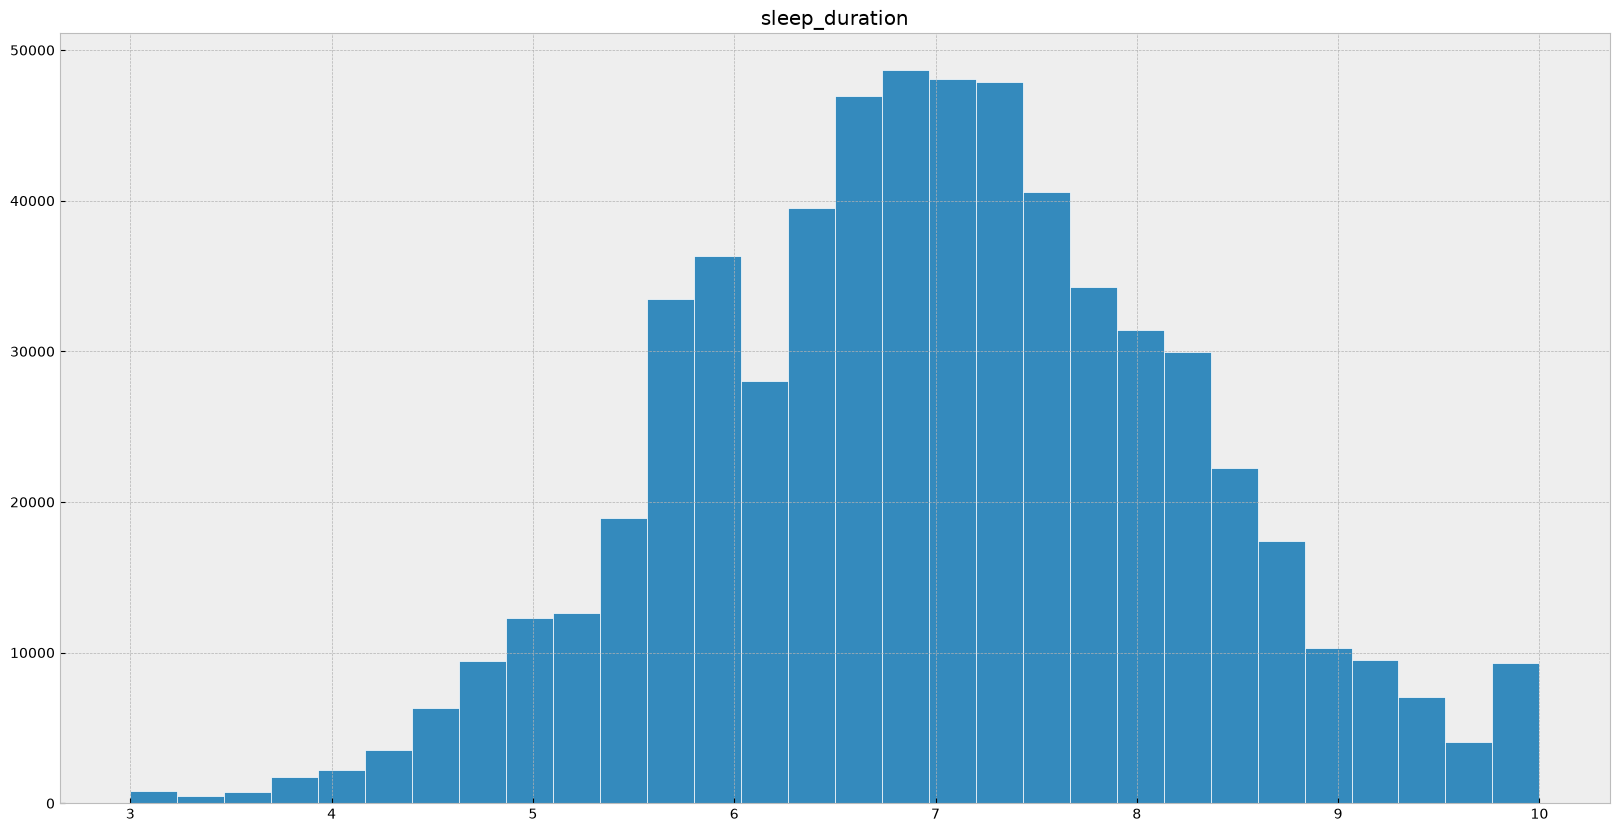

In [4]:
matplotlib.style.use('bmh')
print("全体の睡眠時間")
plt.figure(figsize=(20, 10))
plt.hist(df['sleep_duration'].dropna(), bins=30,edgecolor='white')
plt.title("sleep_duration")
plt.show()

* ７時間前後が多い。これはあくまでもデータの全体のグラフ。

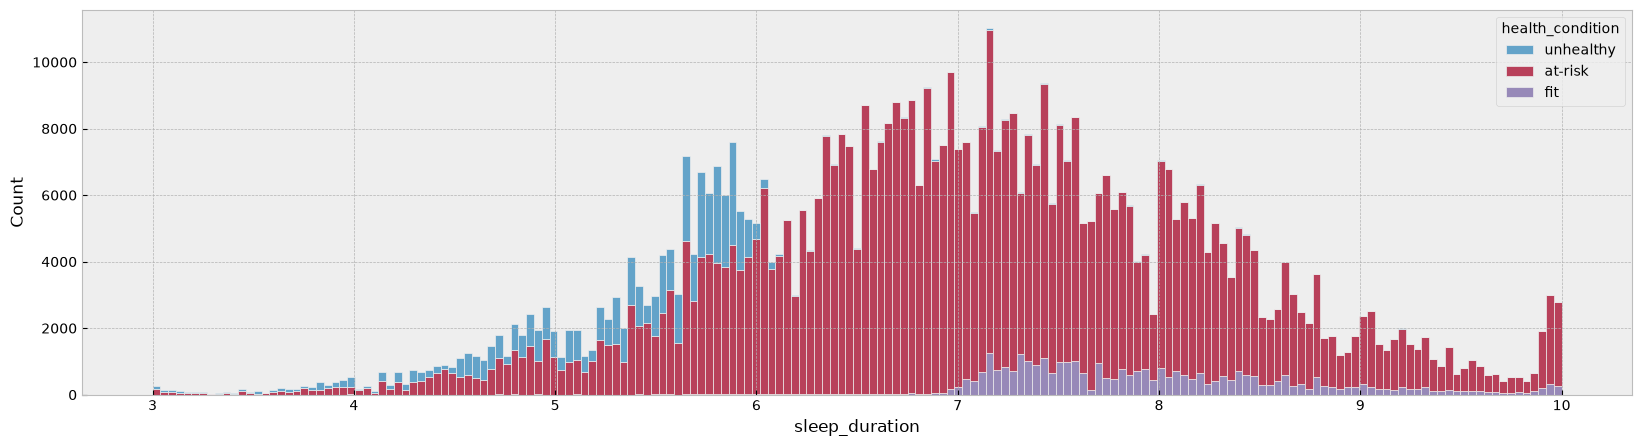

In [5]:
plt.figure(figsize=(20, 5))
sns.histplot(data=df, x='sleep_duration', hue='health_condition', multiple='stack')
plt.xticks()
plt.show()

* **fit**（紫）: 健康的な状態
* **at-risk**（赤）: リスクあり（予備軍）
* **unhealthy**（水色）: 不健康な状態

「睡眠時間が6時間未満だと不健康（unhealthy/水色）な人が多く、<br>
7～10時間しっかり寝ている人の方が健康的（fit/紫）な傾向にある,

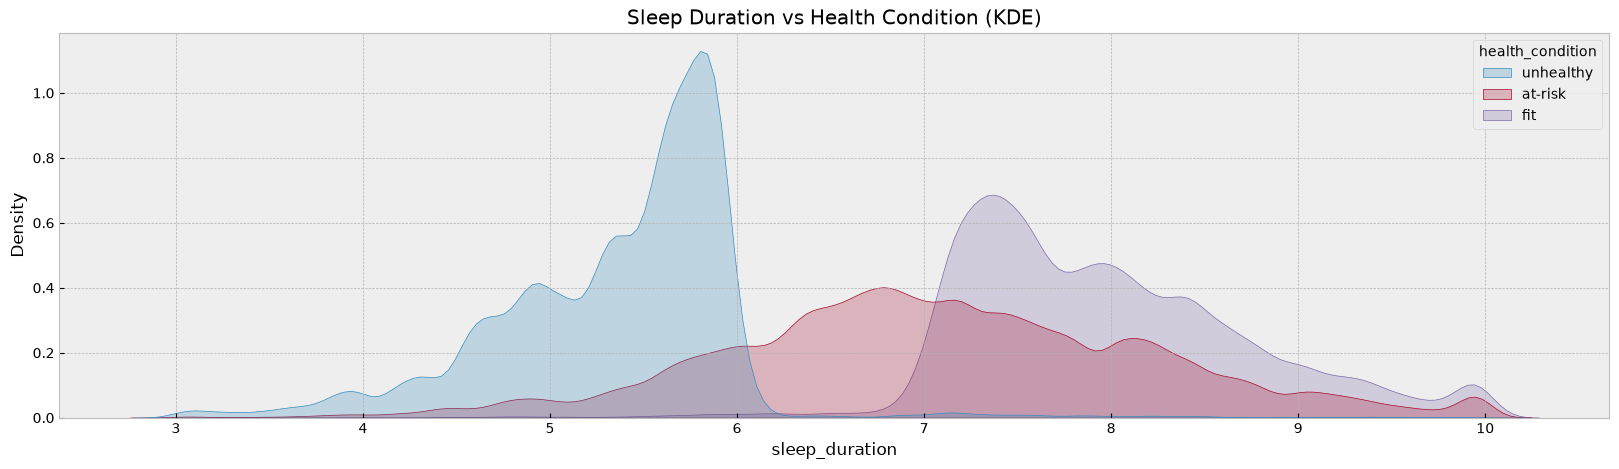

In [6]:
plt.figure(figsize=(20, 5))
sns.kdeplot(data=df, x='sleep_duration', hue='health_condition', fill=True, common_norm=False)
plt.title('Sleep Duration vs Health Condition (KDE)')
plt.show()

* 横軸（下の数字）: 睡眠時間（3時間〜10時間）
* 縦軸（左の数字）: 人の多さ（山が高いほど、その睡眠時間をとっている人が多い）

1) 水色（不健康な状態）の方は**5～6時間の方**が多い
2) 赤色 (リスクあり（予備軍）)の方は**6～8時間**の方が多い
3) 紫色 (健康的な状態)の方は**7～8時間**の方が多い


#### このグラフから分かること（結論）
* 「睡眠時間が短い（5〜6時間）と不健康（unhealthy）な人が多く、しっかり寝ている（7〜8時間）と健康（fit）な人が多い」


In [7]:
df['short_sleep_flag'] = (df['sleep_duration'] < 6.0).astype(int)

In [8]:
df['short_sleep_flag']

0         1
1         1
2         1
3         1
4         0
         ..
690083    0
690084    1
690085    0
690086    0
690087    1
Name: short_sleep_flag, Length: 690088, dtype: int64

新しく特徴量を追加する

* #### 睡眠時間が6時間未満なら「1」、そうでない（空白も含む）なら「0」